# Telco Customer Churn Analysis
### Müşteri Kaybı Analizi: İstatistiksel Modelleme + Makine Öğrenmesi

Bu çalışmada, herkese açık **IBM Telco Customer Churn** veri seti (7.043 müşteri) kullanılarak müşterilerin abonelikten ayrılma (churn) davranışı analiz edilmiştir.

Amaç yalnızca churn tahmini yapmak değil; hangi müşteri özelliklerinin churn ile **ne yönde ve ne güçte ilişkili** olduğunu, karar vericilerin anlayabileceği biçimde çalışılmıştır. Bu nedenle iki tamamlayıcı yaklaşım bir arada kullanılmıştır:

1. **Çıkarımsal istatistik** — odds oranları ve %95 bootstrap güven aralıkları ile lojistik regresyon (*"müşteriler neden gidiyor?"*)
2. **Tahminleyici makine öğrenmesi** — lojistik regresyon ve gradient boosting karşılaştırması (*"bundan sonra kim gidebilir?"*)

> **Okuma kılavuzu:** Her sonuç bölümünde iki tür yorum bulunur:
> ** Analist yorumu** — yöntemsel ve istatistiksel değerlendirme,
> ** Yönetici özeti** — teknik terim içermeyen, aksiyona dönük iş dili.

*Veri kaynağı: [IBM telco-customer-churn-on-icp4d](https://github.com/IBM/telco-customer-churn-on-icp4d). Grafik başlıkları, uluslararası okunabilirlik için bilinçli olarak İngilizce bırakılmıştır.*

## 1. Kurulum ve Yapılandırma

Analizde yalnızca standart veri bilimi kütüphanelerini kullanılmıştır. `BOOTSTRAP_ROUNDS = 200` olarak ayarlanmıştır: yapılan kararlılık denemelerinde 50 yeniden örneklemede güven aralığı sınırlarının rastgele tohuma göre oynadığı, 200 örneklemede ise kararlı hale geldiği görülmüştür.

In [11]:
!pip install -q pandas numpy matplotlib scikit-learn

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA = Path("data/Telco-Customer-Churn.csv")
OUTPUT_DIR = Path("outputs")
BOOTSTRAP_ROUNDS = 200
RANDOM_STATE = 42

def make_one_hot_encoder():

    try:
        return OneHotEncoder(drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop="first", sparse=False)

## 2. Veri Setinin Yüklenmesi

Veri seti, tam yeniden üretilebilirlik için doğrudan kaynağından (GitHub) indirilebilir. **Runtime → Run all** ile notebook baştan sona çalışacaktır.

Veri setinde 7.043 müşteri kaydı bulunmaktadır. Hedef değişken `Churn` kolonudur: `Yes` müşterinin hizmetten ayrıldığını, `No` kalmaya devam ettiğini göstermektedir. Analizde özellikle kontrat tipi, abonelik süresi, internet hizmeti tipi, ödeme yöntemi, aylık ücret ve ek hizmet kullanımı değişkenleri incelenmiştir.

In [12]:
URL = ("https://raw.githubusercontent.com/IBM/"
       "telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")

Path("data").mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA.exists():
    pd.read_csv(URL).to_csv(DATA, index=False)

print(f"Veri seti hazır: {DATA}")

Veri seti hazır: data/Telco-Customer-Churn.csv


## 3. Veri Temizliği

İki bilinen veri kalitesi sorunu ele alınmaktadır: (1) `TotalCharges` metin tipindedir ve abonelik süresi 0 olan 11 müşteride boş değer içermektedir — sayısala çevrilip 0 ile doldurulur; (2) `customerID` her satırda benzersiz bir kimliktir, modele bilgi taşımaz ve çıkarılır.

In [13]:
def load_and_clean() -> pd.DataFrame:
    df = pd.read_csv(DATA)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"] = df["TotalCharges"].fillna(0)  # tenure=0 olan 11 müşteri
    df["Churn"] = (df["Churn"] == "Yes").astype(int)
    return df.drop(columns=["customerID"])

df = load_and_clean()
print(f"Müşteri sayısı : {df.shape[0]}")
print(f"Değişken sayısı: {df.shape[1]}")
print(f"Churn oranı    : {df.Churn.mean():.1%}")
display(df.head())

Müşteri sayısı : 7043
Değişken sayısı: 20
Churn oranı    : 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 4. Keşifsel Veri Analizi (EDA)

Modellemeye geçmeden önce churn'ün üç temel boyutla ilişkisi görselleştirilmiştir. Bunlar; Kontrat tipi, abonelik süresi ve internet hizmeti tipi.

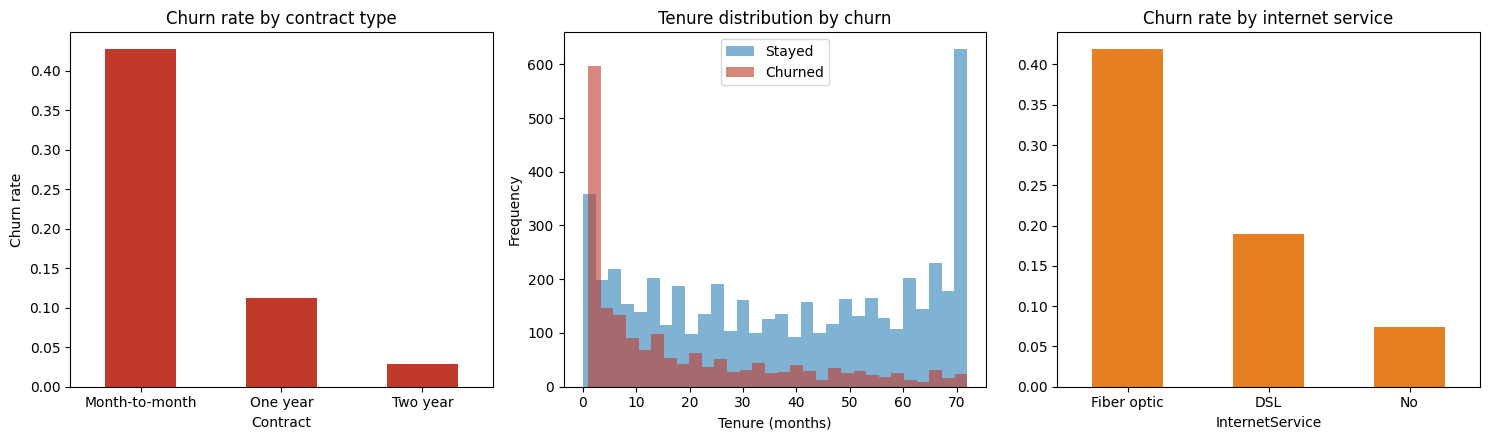

In [15]:
def eda_figures(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    rate = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
    rate.plot.bar(ax=axes[0], color="#c0392b", rot=0)
    axes[0].set_title("Churn rate by contract type")
    axes[0].set_ylabel("Churn rate")

    df[df.Churn == 0]["tenure"].plot.hist(ax=axes[1], bins=30, alpha=0.6,
                                          label="Stayed", color="#2c7fb8")
    df[df.Churn == 1]["tenure"].plot.hist(ax=axes[1], bins=30, alpha=0.6,
                                          label="Churned", color="#c0392b")
    axes[1].set_title("Tenure distribution by churn")
    axes[1].set_xlabel("Tenure (months)")
    axes[1].legend()

    rate2 = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)
    rate2.plot.bar(ax=axes[2], color="#e67e22", rot=0)
    axes[2].set_title("Churn rate by internet service")

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "eda_overview.png", dpi=150)
    plt.show()

eda_figures(df)

### Keşifsel Analiz Yorumu

**Analist yorumu:** Churn oranı en yüksek grup aylık (month-to-month) kontrata sahip müşterilerdir; bir ve iki yıllık kontratlarda oran belirgin şekilde düşmektedir. Abonelik süresi dağılımı da tutarlı bir örüntü vermekte olup: ayrılan müşteriler ilk aylarda yoğunlaşırken, uzun süreli müşterilerde ayrılma seyrekleşmektedir. Fiber optik kullanıcılarında churn oranının yüksek olması dikkat çekicidir; bu bulgu tek değişkenli bir gözlemdir ve fiyat algısı, beklenti düzeyi veya segment yapısıyla karışmış (confounded) olabilir. Çok değişkenli modelde yeniden değerlendirilecektir.

**Yönetici özeti:**  Müşteri kaybı rastgele dağılmamaktadır. Sözleşmesiz (aydan aya) müşteriler en kırılgan grup olarak görünmektedir. Ayrıca kaybedilen müşterilerin çoğu daha ilk aylarda kaybedilmektedir. Yeni müşteriyi ilk 6 ayda elde tutmak, uzun süreli müşteriyi tutmaktan çok daha zordur. Fiber internet müşterilerinde de kayıp yüksek görünmektedir. Bu, en yüksek gelirli üründe bir memnuniyet sinyali olabilir ve ayrıca incelenmelidir.

## 5. Çıkarımsal Analiz: Lojistik Regresyon ve Odds Oranları

**Yöntem notları :**
- Sayısal değişkenler **standartlaştırılmıştır**; bu nedenle sayısal değişkenlerin odds oranları *1 standart sapmalık artış başına* yorumlanmalıdır (ör. `tenure` için ~24 ay).
- Kategorik değişkenler referans kategori düşürülerek (drop-first) one-hot kodlanmıştır; her odds oranı ilgili referans kategoriye göredir.
- Güven aralıkları, **200 yeniden örneklemeli bootstrap** ile katsayıların 2.5 ve 97.5 yüzdeliklerinden elde edilmiştir.
- Tablodaki `significant = True`, %95 bootstrap güven aralığının 1 değerini dışladığını, yani etkinin istatistiksel olarak sıfırdan ayırt edilebildiğini gösterir.
- Odds oranı > 1 churn ile pozitif, < 1 negatif ilişkiyi ifade eder.

In [16]:
def logistic_odds_ratios(df: pd.DataFrame) -> pd.DataFrame:
    y = df["Churn"].to_numpy()
    X = df.drop(columns="Churn")
    cat = X.select_dtypes(exclude="number").columns.tolist()
    num = X.select_dtypes("number").columns.tolist()

    pre = ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", make_one_hot_encoder(), cat),
    ])
    Xt = pre.fit_transform(X)
    names = pre.get_feature_names_out()

    lr = LogisticRegression(max_iter=1000, C=1.0, solver="liblinear")
    lr.fit(Xt, y)

    rng = np.random.default_rng(0)
    boots = []
    for _ in range(BOOTSTRAP_ROUNDS):
        idx = rng.integers(0, len(y), len(y))
        b = LogisticRegression(max_iter=1000, C=1.0, solver="liblinear").fit(Xt[idx], y[idx])
        boots.append(b.coef_[0])
    lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)

    table = pd.DataFrame({
        "odds_ratio": np.exp(lr.coef_[0]),
        "ci_low": np.exp(lo),
        "ci_high": np.exp(hi),
    }, index=names)
    table["significant"] = (table.ci_low > 1) | (table.ci_high < 1)
    return table.sort_values("odds_ratio", ascending=False).round(3)

odds = logistic_odds_ratios(df)
odds.to_csv(OUTPUT_DIR / "odds_ratios.csv")

print("=== Churn ile en güçlü pozitif ilişkili faktörler ===")
display(odds.head(8))
print("=== En güçlü koruyucu faktörler ===")
display(odds.tail(5))

=== Churn ile en güçlü pozitif ilişkili faktörler ===


,odds_ratio,ci_low,ci_high,significant
cat__InternetService_Fiber optic,2.079,1.342,3.365,True
num__TotalCharges,1.990,1.474,2.666,True
cat__PaperlessBilling_Yes,1.406,1.231,1.644,True
cat__PaymentMethod_Electronic check,1.352,1.115,1.578,True
cat__MultipleLines_Yes,1.274,1.112,1.502,True
cat__StreamingMovies_Yes,1.216,0.973,1.485,False
cat__StreamingTV_Yes,1.203,0.947,1.492,False
num__SeniorCitizen,1.083,1.025,1.154,True


=== En güçlü koruyucu faktörler ===


,odds_ratio,ci_low,ci_high,significant
cat__OnlineSecurity_Yes,0.664,0.550,0.769,True
cat__Contract_One year,0.518,0.427,0.648,True
cat__PhoneService_Yes,0.472,0.413,0.535,True
cat__Contract_Two year,0.261,0.172,0.363,True
num__tenure,0.240,0.178,0.318,True


### Odds Oranı Yorumu

**Analist yorumu:** Fiber optik internet hizmeti, electronic check ödeme yöntemi ve paperless billing, churn ile anlamlı pozitif ilişki gösteren başlıca değişkenlerdir. Koruyucu tarafta iki yıllık kontrat (OR ≈ 0.26) ve abonelik süresi (OR ≈ 0.24, 1 SS ≈ 24 ay başına) öne çıkar; online security gibi ek hizmet bağlılığı da churn olasılığını düşürmektedir. Sayısal değişkenler standartlaştırıldığı için bu odds oranları birim başına değil, standart sapma başına etki büyüklüğüdür. Bulgular gözlemsel veriye dayandığından **nedensellik değil, ilişki** olarak yorumlanmalıdır; örneğin fiber optikteki yüksek churn, hizmetin kendisinden değil bu segmentin fiyat ve beklenti profilinden kaynaklanıyor olabilir.

**Yönetici özeti:** Rakamlar üç net bilgiyi göstermektedir.

1- İki yıllık sözleşmesi olan bir müşterinin ayrılma ihtimali, aydan aya müşteriye göre yaklaşık dörtte bir kadardır. Müşteriyi uzun sözleşmeye ikna eden her kampanya, doğrudan kayıp oranını düşürecektir.

2- Sadakat, müşteri ne kadar uzun süredir kalmışsa, gitme ihtimali o kadar düşmektedir. Kritik dönem ilk aylardır.

3- Elektronik çekle ödeme yapanlar ayrı bir riskli kesim olarak görünmektedir.
Bu ödeme yöntemini kullananları otomatik ödeme veya kredi kartına taşımak, düşük maliyetli bir tutundurma fırsatı olabilir.

 Bu bulgular "neyin birlikte görüldüğünü" göstermektedir, "neyin neye yol açtığını" kanıtlamamaktadır. Kesin konuşmak için pilot kampanyayla test etmek gerekir.

## 6. Tahminleyici Modelleme

Veri, tabakalı (stratified) örnekleme ile %75 eğitim / %25 test olarak bölünmüştür. Model seçimi eğitim kümesi üzerinde
5 katlı çapraz doğrulama ile değerlendirilmiş, nihai performans ayrılmış test kümesinde ROC-AUC ile raporlanmıştır.
Gradient boosting için bilinçli olarak sığ bir yapılandırma (60 ağaç, derinlik 2) tercih edilmiştir.Yapılan denemelerde bu ayar varsayılan yapılandırmayla aynı test performansını (AUC ≈ 0.85) daha kısa sürede ve daha düşük aşırı öğrenme riskiyle vermektedir.


=== LogisticRegression (test set) ===
              precision    recall  f1-score   support

           0      0.849     0.897     0.872      1294
           1      0.662     0.557     0.605       467

    accuracy                          0.807      1761
   macro avg      0.755     0.727     0.738      1761
weighted avg      0.799     0.807     0.801      1761


=== GradientBoosting (test set) ===
              precision    recall  f1-score   support

           0      0.825     0.917     0.869      1294
           1      0.667     0.463     0.546       467

    accuracy                          0.796      1761
   macro avg      0.746     0.690     0.707      1761
weighted avg      0.783     0.796     0.783      1761



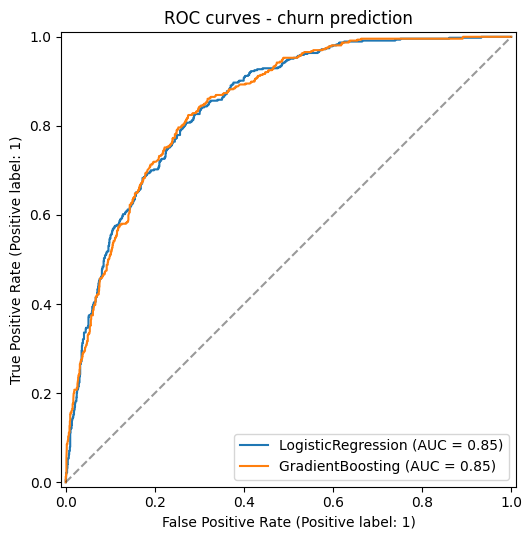

=== Model karşılaştırması ===


,cv_auc_mean,cv_auc_sd,test_auc
LogisticRegression,0.844,0.013,0.847
GradientBoosting,0.847,0.013,0.847


In [17]:
def predictive_models(df: pd.DataFrame) -> pd.DataFrame:
    y = df["Churn"].to_numpy()
    X = df.drop(columns="Churn")
    cat = X.select_dtypes(exclude="number").columns.tolist()
    num = X.select_dtypes("number").columns.tolist()

    pre = ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", make_one_hot_encoder(), cat),
    ])

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
        "Gradient Boosting": GradientBoostingClassifier(
            random_state=0, n_estimators=60, max_depth=2),
    }

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    results = {}
    for name, clf in models.items():
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        cv_auc = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="roc_auc")
        pipe.fit(X_tr, y_tr)
        proba = pipe.predict_proba(X_te)[:, 1]
        results[name] = {
            "cv_auc_mean": cv_auc.mean(),
            "cv_auc_sd": cv_auc.std(),
            "test_auc": roc_auc_score(y_te, proba),
        }
        RocCurveDisplay.from_predictions(y_te, proba, name=name, ax=ax)
        print(f"\n=== {name} (test set) ===")
        print(classification_report(y_te, (proba >= 0.5).astype(int), digits=3))

    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title("ROC curves - churn prediction")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "roc_curves.png", dpi=150)
    plt.show()
    return pd.DataFrame(results).T.round(3)

summary = predictive_models(df)
summary.to_csv(OUTPUT_DIR / "model_comparison.csv")
print("=== Model Comparison ===")
display(summary)

### Model Sonuçları Yorumu

**Analist yorumu:** Her iki model de test kümesinde yaklaşık **0.85 AUC** üretmektedir; gradient boosting'in ek esnekliği bu veri setinde ölçülebilir bir avantaj sağlamamıştır. Bu durumda açıklanabilirliği yüksek olan lojistik regresyon tercih edilmelidir: katsayıları odds oranı olarak doğrudan yorumlanabilir ve Bölüm 5'teki çıkarımsal analizle tutarlı tek bir anlatı sunar. Sınıflandırma raporunda varsayılan **0.5 karar eşiği** kullanılmıştır; churn sınıfının duyarlılığı (recall ≈ 0.55) bu eşikte sınırlıdır. Gerçek bir kampanya senaryosunda eşik, kaçırılan churn maliyeti ile gereksiz kampanya maliyeti arasındaki dengeye göre ayarlanmalı, gerekirse maliyet-duyarlı öğrenme veya eşik optimizasyonu uygulanmalıdır.

**Yönetici özeti:** Kurulmuş olan model, müşterileri churn riski açısından anlamlı şekilde sıralayabilmektedir.
Bu sayede "hangi müşterilere öncelik verelim?" "kime kampanya yapalım?" sorusunda rastgele seçim yapmak yerine veriye dayalı bir hedef liste oluşturulabilinir.

İki farklı model denenmiştir. Daha karmaşık olan Gradient Boosting modeli, daha basit olan Logistic Regression modelinden belirgin şekilde daha iyi sonuç vermemiştir. Bu aslında operasyon açısından olumlu bir sonuçtur. Çünkü daha basit modelin çıktıları daha kolay açıklanabilir ve iş ekipleri tarafından daha rahat kullanılabilir.

Örneğin model, bir müşterinin neden riskli olduğunu anlaşılır şekilde gösterebilir. Kısa süredir müşteri olması, aylık kontrata sahip olması, fiber optic internet kullanması veya belirli ödeme yöntemlerini tercih etmesi gibi faktörler churn riskini artırabilir.

Buradaki önemli karar, modelin ne kadar hassas çalıştırılacağıdır. Daha geniş bir müşteri listesi seçersek churn etme ihtimali olan daha fazla müşteriye ulaşabiliriz; ancak kampanya maliyeti artar. Daha dar bir liste seçersek maliyet düşer; fakat ayrılma riski olan bazı müşteriler kaçabilir.

Bu nedenle model çıktısı tek başına bir kampanya kararı olarak görülmemelidir. Kampanya bütçesi, müşteri değeri ve churn eden müşteriyi kaybetmenin maliyeti birlikte değerlendirilerek hedef müşteri listesi oluşturulmalıdır.

## 7. Genel Değerlendirme

** Analist değerlendirme**

Analiz, müşteri kaybının rastgele gerçekleşmediğini; belirli kontrat yapıları, hizmet tercihleri ve ödeme alışkanlıkları etrafında yoğunlaştığını göstermektedir. Veri setindeki müşterilerin yaklaşık dörtte biri (%26,5) hizmetten **ayrılmıştır**. Bu, gelecekteki bir risk tahmini değil, gerçekleşmiş kayıp oranıdır ve problemin yapısal ölçeğini gösterir.

En güçlü bulgu kontrat tipidir. İki yıllık kontrat, aylık kontrata göre ayrılma olasılığını yaklaşık dörtte bire indirmektedir (OR ≈ 0.26). Abonelik süresi de benzer güçte koruyucudur; churn ilk aylarda yoğunlaşmaktadır. Fiber optik segmentindeki yüksek churn tek başına hizmet kalitesi sorunu olarak okunmamalı; fiyat beklentisi, rekabet baskısı ve segment kompozisyonu gibi karıştırıcı etkenler dışlanmamalıdır.

**Sınırlılıklar:** (1) Bulgular gözlemsel veriye dayanır; nedensellik değil ilişki ifade eder. (2) Veri tek bir zaman kesitidir; zamana bağlı dinamikler için sağkalım analizi (Cox PH) daha uygun olur. (3) Model, kampanya maliyeti ve müşteri yaşam boyu değeri (CLV) gibi iş metriklerini içermez; üretim kullanımı öncesinde karar eşiği bu metriklerle optimize edilmelidir.

**Yönetici özeti**

Elimizdeki tabloda  **her dört müşteriden biri kaybedilmiştir**
Kaybedilenler sözleşmesiz, yeni ve elektronik çekle ödeyen müşterilerdir. Buna karşılık uzun sözleşmeli ve köklü müşteriler güvende görünmektedir.

Önerilen aksiyonlar ise:

1. Sözleşmeye geçiş kampanyası: Aydan aya müşterileri yıllık sözleşmeye taşıyan teklifler sunulabilir; verideki en güçlü kaldıraç budur.
2. İlk 6 ay programı : Yeni müşteriler için karşılama, memnuniyet takibi ve proaktif destek akışı; kayıp en çok burada gerçekleşmektedir.
3. Fiber segmenti incelemesi: En değerli üründeki yüksek kayıp için fiyat, performans algısı ve destek deneyimi ayrıca analiz edilmelidir.
4. Ödeme deneyimi: Elektronik çek kullanıcıları otomatik ödemeye taşıma teşvik edilmelidir.
5. Risk skoruna dayalı tutundurma: Modelin ürettiği churn skoru yüksek müşterilere proaktif arama yapılarak, paket iyileştirme veya sadakat teklifi yapılabilir.

Bu çalışma üretime hazır nihai bir sistem değil, riskli segmentleri belirleyen güçlü bir başlangıç analizidir. Bir sonraki adım, önerilen aksiyonlardan birinin küçük bir pilot kampanyayla test edilmesi ve geri dönüşünün ölçülmesidir — böylece "ilişki" düzeyindeki bulgular "kanıtlanmış etki"ye dönüşebilir.